<a href="https://colab.research.google.com/github/jairbenavides0520-dotcom/Jair/blob/main/Actividades%20IA/PIA_IA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Martes N4-N6

Garza Elizondo Raúl Alejandro - 2066224

Aguirre Hernández Jesús Román - 2053240

Benavides García Jair Eduardo - 2052989

Barba Botello Montserrat Sarahi - 2041504

LMV

Flores Garza Jesus Alberto - 1910136

Gonzalez Cabriales Brisseida Esmeralda - 1974257

Metodología:

1. Preparación del Dataset

Se creó un conjunto de imágenes organizado en carpetas para clasificar dos categorías: rostro autorizado y rostros no autorizados.
Se utilizó la clase ImageDataGenerator para:

•	Normalizar las imágenes (rescale).
•	Generar aumentos de datos (rotaciones, desplazamientos, zoom y volteos).

•	Dividir el dataset en training (80%) y validation (20%).

Esto nos ayudó a  mejorar la capacidad del modelo para generalizar y evitar el sobreajuste.

2. Diseño del Modelo de Reconocimiento Facial

Se creó una CNN compuesta por:

•	Tres bloques de Conv2D + MaxPooling para extracción de características.

•	Una capa Flatten y una capa Dense con regularización L2.

•	Una capa Dropout para reducir sobreajuste.

•	Una capa de salida con activación sigmoid para clasificación binaria (rostro válido/no válido).

El modelo se compiló usando el optimizador Adam y la función de pérdida binary_crossentropy.


3. Entrenamiento del Modelo

El modelo se entrenó durante un máximo de 20 épocas utilizando:

•	EarlyStopping para detener el entrenamiento al detectar estancamiento.

Durante el entrenamiento se monitorizó:

•	Precisión de entrenamiento.

•	Precisión en validación.

4. Evaluación y Validación
Al finalizar, el modelo se evaluó con los datos de validación para verificar su desempeño real.
Se obtuvo el valor de:

•	Exactitud final del modelo (accuracy).

También se generaron gráficas de desempeño para observar la evolución del aprendizaje.

5. Implementación en el Sistema de Control de la Puerta

El modelo final se guardó en formato .keras, permitiendo su uso en la Raspberry Pi.
El flujo operativo del sistema es:

1.	La cámara captura un rostro.

2.	El modelo clasifica la imagen.

3.	Si el rostro coincide con el autorizado:

•	Se activa el motor 1 para quitar el seguro.

•	Se activa el motor 2 para abrir la puerta.

4.	Después, se ejecuta la secuencia inversa para cerrar y asegurar la puerta.

5.	El sistema vuelve automáticamente al estado de detección continua.


In [1]:
import zipfile
import os

zip_path = "dataset.zip"  # nombre del archivo subido
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall()

print("Dataset listo.")
print(os.listdir("dataset"))

Dataset listo.
['persona_autorizada', 'desconocidos']


TensorFlow versión: 2.19.0
Found 120 images belonging to 2 classes.
Found 30 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 619ms/step - accuracy: 0.6365 - loss: 0.9307 - val_accuracy: 0.6667 - val_loss: 0.8082
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 639ms/step - accuracy: 0.6758 - loss: 0.7973 - val_accuracy: 0.6667 - val_loss: 0.7315
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 516ms/step - accuracy: 0.6707 - loss: 0.7525 - val_accuracy: 0.6667 - val_loss: 0.6609
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 556ms/step - accuracy: 0.6918 - loss: 0.7015 - val_accuracy: 0.6667 - val_loss: 0.5988
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 720ms/step - accuracy: 0.7355 - loss: 0.6116 - val_accuracy: 0.6667 - val_loss: 0.7101
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 525ms/step - accuracy: 0.7761 - loss: 0.5136 - val_accuracy: 0.9667 - val_loss: 0.3789
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 491ms/step - accuracy: 0.8019 - loss: 0.5176 - val_accuracy: 0.8333 - val_loss: 0.4918
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 684ms/step - accuracy: 0.8028 - loss: 0.4823 - val_accuracy: 0.8333 - val_loss:

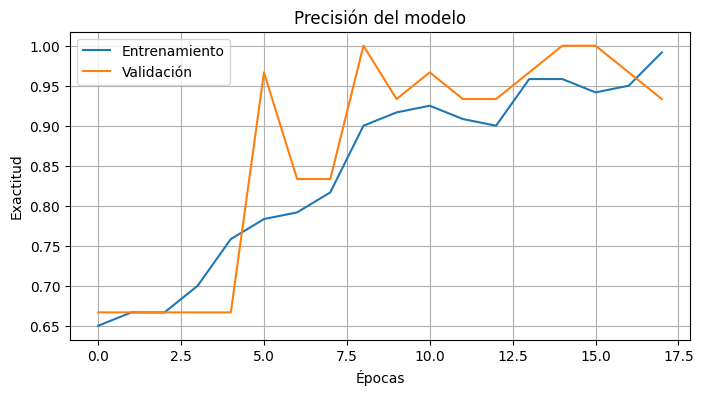

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt

print("TensorFlow versión:", tf.__version__)

ruta_dataset = "dataset/"

# Generador de datos con aumento (data augmentation)
data_gen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

train_data = data_gen.flow_from_directory(
    ruta_dataset,
    target_size=(100, 100),
    batch_size=16,
    class_mode='binary',
    subset='training'
)

val_data = data_gen.flow_from_directory(
    ruta_dataset,
    target_size=(100, 100),
    batch_size=16,
    class_mode='binary',
    subset='validation'
)

# Modelo CNN mejorado
model = keras.Sequential([
    keras.layers.Input(shape=(100,100,3)),

    keras.layers.Conv2D(32, (3,3), activation='relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Conv2D(64, (3,3), activation='relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Conv2D(128, (3,3), activation='relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Flatten(),
    keras.layers.Dropout(0.5),  # Previene sobreajuste
    keras.layers.Dense(128, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
    keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
checkpoint = ModelCheckpoint('mejor_modelo.keras', save_best_only=True, monitor='val_accuracy')

# Entrenamiento
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    verbose=1,
    callbacks=[early_stop, checkpoint]
)

# Evaluación
test_loss, test_acc = model.evaluate(val_data, verbose=2)
print(f"\nExactitud del modelo en datos de prueba: {test_acc:.4f}")

# Guardar modelo final
model.save("modelo_reconocimiento_facial_mejorado.keras")
print("\nModelo guardado como modelo_reconocimiento_facial_mejorado.keras")

# Gráficas
plt.figure(figsize=(8,4))
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Precisión del modelo')
plt.xlabel('Épocas')
plt.ylabel('Exactitud')
plt.legend()
plt.grid(True)
plt.show()
